In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import requests
import time
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{DEVICE}")

plt.style.use('seaborn-v0_8')

cpu


In [2]:
class BinanceDataLoader:
    def __init__(self):
        self.base_url = "https://fapi.binance.com/fapi/v1/klines"

    def fetch_data(self, symbol="BTCUSDT", interval="1h", start_str=None, end_str=None):
        all_data = []
        params = {"symbol": symbol, "interval": interval, "limit": 1500}
        
        if start_str:
            start_ts = int(pd.Timestamp(start_str).timestamp() * 1000)
            params["startTime"] = start_ts
            
        end_ts = int(pd.Timestamp(end_str).timestamp() * 1000) if end_str else int(time.time() * 1000)

        print(f"Đang tải dữ liệu {symbol} từ {start_str}...", end=" ")
        
        while True:
            try:
                response = requests.get(self.base_url, params=params)
                data = response.json()
                
                if not data or not isinstance(data, list):
                    break
                
                df = pd.DataFrame(data, columns=[
                    "timestamp", "open", "high", "low", "close", "volume",
                    "close_time", "q_vol", "trades", "taker_base", "taker_quote", "ignore"
                ])
                
                # Convert kiểu dữ liệu
                cols = ["open", "high", "low", "close", "volume"]
                df[cols] = df[cols].astype(float)
                df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")
                
                all_data.append(df)
                
                # Kiểm tra điều kiện dừng
                last_ts = df.iloc[-1]["timestamp"]
                if last_ts >= end_ts or len(df) < 100:
                    break
                    
                # Cập nhật startTime cho batch tiếp theo
                params["startTime"] = int(last_ts) + 1
                time.sleep(0.1) # Tránh bị chặn IP
                
            except Exception as e:
                print(f"\nLỗi tải dữ liệu: {e}")
                break

        if not all_data:
            return pd.DataFrame()
            
        final_df = pd.concat(all_data, ignore_index=True)
        final_df = final_df.set_index("datetime").sort_index()
        
        # Cắt đúng khoảng thời gian yêu cầu
        if end_str:
            final_df = final_df[:end_str]
            
        print(f"-> Hoàn tất: {len(final_df)} nến.")
        return final_df

def load_and_process_sentiment(csv_path):
    """Đọc file sentiment và gom nhóm theo giờ"""
    print(f"Đang xử lý file sentiment: {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # 1. Chuyển đổi cột Date
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    
    # 2. Resample về khung 1 Giờ (1H)
    # Vì một giờ có thể có nhiều tin -> Lấy trung bình cộng sentiment
    df_resampled = df['Accurate Sentiments'].resample('1h').mean()
    
    # Đổi tên thành Series cho dễ merge
    df_resampled.name = 'sentiment'
    
    return df_resampled

In [3]:
def prepare_dataset(sentiment_file, symbol="BTCUSDT", window_size=60):
    # --- 1. Load Sentiment ---
    series_sentiment = load_and_process_sentiment(sentiment_file)
    
    # Lấy ngày bắt đầu và kết thúc từ file sentiment để tải giá cho khớp
    start_date = series_sentiment.index.min().strftime('%Y-%m-%d')
    end_date = series_sentiment.index.max().strftime('%Y-%m-%d')
    
    # --- 2. Load Price Data from Binance ---
    loader = BinanceDataLoader()
    df_price = loader.fetch_data(symbol, interval="1h", start_str=start_date, end_str=end_date)
    
    # --- 3. Merge Data ---
    # Join sentiment vào bảng giá dựa trên index (datetime)
    df_merged = df_price.join(series_sentiment, how='left')
    
    # Xử lý Missing Value
    # Nếu giờ đó không có tin tức -> Fill 0 (Trung lập) hoặc dùng ffill (giữ tin cũ)
    # Ở đây ta dùng fill 0 để an toàn
    df_merged['sentiment'] = df_merged['sentiment'].fillna(0)
    
    # Loại bỏ các dòng thiếu dữ liệu giá (nếu có)
    df_merged.dropna(subset=['close'], inplace=True)
    
    print(f"Dữ liệu sau khi merge: {df_merged.shape}")
    
    # --- 4. Scaling (Chuẩn hóa) ---
    feature_cols = ['open', 'high', 'low', 'close', 'volume', 'sentiment']
    target_col = 'close'  # Mục tiêu dự đoán

    # Tách Scaler riêng cho X và y để dễ inverse sau này
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    scaled_data = scaler_X.fit_transform(df_merged[feature_cols])
    
    # Fit riêng cột close cho scaler_y
    scaler_y.fit(df_merged[[target_col]])

    # --- 5. Tạo Sliding Window ---
    X, y = [], []
    # Cột 'close' nằm ở vị trí thứ 3 trong feature_cols
    target_idx = feature_cols.index(target_col) 
    
    for i in range(window_size, len(scaled_data)):
        # Input: window_size dòng quá khứ
        X.append(scaled_data[i-window_size:i, :]) 
        # Output: Giá close tại thời điểm hiện tại
        y.append(scaled_data[i, target_idx])
        
    X = torch.FloatTensor(np.array(X))
    y = torch.FloatTensor(np.array(y)).unsqueeze(1)  # Shape (N, 1)
    
    return X, y, scaler_X, scaler_y, df_merged.index[window_size:]

# === THỰC THI PIPELINE ===
FILE_NAME = 'bitcoin_sentiments_21_24.csv'  # Tên file bạn đã upload
WINDOW_SIZE = 24  # Dùng 24h quá khứ để dự đoán

# Chạy hàm
try:
    X, y, scaler_X, scaler_y, time_index = prepare_dataset(FILE_NAME, window_size=WINDOW_SIZE)
    
    # Chia Train/Test (80/20)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    test_times = time_index[split:]

    print(f"\nKích thước tập Train: {X_train.shape}")
    print(f"Kích thước tập Test: {X_test.shape}")
    
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file '{FILE_NAME}'. Hãy đảm bảo bạn đã upload file này.")

Đang xử lý file sentiment: bitcoin_sentiments_21_24.csv...
Đang tải dữ liệu BTCUSDT từ 2021-11-05... 

-> Hoàn tất: 25032 nến.
Dữ liệu sau khi merge: (25032, 13)

Kích thước tập Train: torch.Size([20006, 24, 6])
Kích thước tập Test: torch.Size([5002, 24, 6])


In [4]:
import os

class CryptoPredictor(nn.Module):
    """
    LSTM-based model for cryptocurrency price prediction.
    Uses price data (OHLCV) and sentiment features.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1, dropout=0.2):
        super(CryptoPredictor, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.output_dim = output_dim
        self.dropout = dropout
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: (Batch, Seq_Len, Features)
        out, _ = self.lstm(x)
        
        # Lấy output tại bước thời gian cuối cùng
        last_out = out[:, -1, :]
        prediction = self.fc(last_out)
        return prediction
    
    @classmethod
    def load_model(cls, model_path: str, device: torch.device = None):
        """Load model from checkpoint file."""
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
        
        # Recreate model with saved config
        config = checkpoint['model_config']
        model = cls(
            input_dim=config['input_dim'],
            hidden_dim=config['hidden_dim'],
            num_layers=config['num_layers'],
            output_dim=config['output_dim'],
            dropout=config['dropout']
        )
        
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        model.eval()
        
        return model, checkpoint
    
    def save_model(self, path: str, scaler_X=None, scaler_y=None, 
                   feature_cols=None, window_size=None, extra_info=None):
        """
        Save model checkpoint with all necessary info for inference.
        
        Args:
            path: Path to save the model
            scaler_X: MinMaxScaler for input features
            scaler_y: MinMaxScaler for target
            feature_cols: List of feature column names
            window_size: Sliding window size used
            extra_info: Any additional metadata
        """
        checkpoint = {
            'model_config': {
                'input_dim': self.input_dim,
                'hidden_dim': self.hidden_dim,
                'num_layers': self.num_layers,
                'output_dim': self.output_dim,
                'dropout': self.dropout,
            },
            'model_state_dict': self.state_dict(),
            'feature_cols': feature_cols or ['open', 'high', 'low', 'close', 'volume', 'sentiment'],
            'window_size': window_size,
        }
        
        # Save scalers if provided
        if scaler_X is not None:
            checkpoint['scaler_X'] = {
                'min_': scaler_X.min_.tolist(),
                'scale_': scaler_X.scale_.tolist(),
                'data_min_': scaler_X.data_min_.tolist(),
                'data_max_': scaler_X.data_max_.tolist(),
                'data_range_': scaler_X.data_range_.tolist(),
            }
        
        if scaler_y is not None:
            checkpoint['scaler_y'] = {
                'min_': scaler_y.min_.tolist(),
                'scale_': scaler_y.scale_.tolist(),
                'data_min_': scaler_y.data_min_.tolist(),
                'data_max_': scaler_y.data_max_.tolist(),
                'data_range_': scaler_y.data_range_.tolist(),
            }
            
        if extra_info:
            checkpoint['extra_info'] = extra_info
            
        # Create directory if not exists
        os.makedirs(os.path.dirname(path) if os.path.dirname(path) else '.', exist_ok=True)
        
        torch.save(checkpoint, path)
        print(f"Model saved to: {path}")
        
        return path


Bắt đầu huấn luyện...
Epoch [5/50], Loss: 0.000103, Best: 0.000103, LR: 0.001000
Epoch [10/50], Loss: 0.000079, Best: 0.000079, LR: 0.001000
Epoch [15/50], Loss: 0.000069, Best: 0.000069, LR: 0.001000
Epoch [20/50], Loss: 0.000056, Best: 0.000056, LR: 0.001000
Epoch [25/50], Loss: 0.000052, Best: 0.000052, LR: 0.001000
Epoch [30/50], Loss: 0.000052, Best: 0.000048, LR: 0.001000
Epoch [35/50], Loss: 0.000045, Best: 0.000045, LR: 0.001000
Epoch [40/50], Loss: 0.000038, Best: 0.000038, LR: 0.001000
Epoch [45/50], Loss: 0.000036, Best: 0.000036, LR: 0.001000
Epoch [50/50], Loss: 0.000036, Best: 0.000035, LR: 0.001000

=> RMSE trên tập Test: 722.29 USD
Đang lưu model vào crypto_predictor_btcusdt.pt...
Model saved to: crypto_predictor_btcusdt.pt


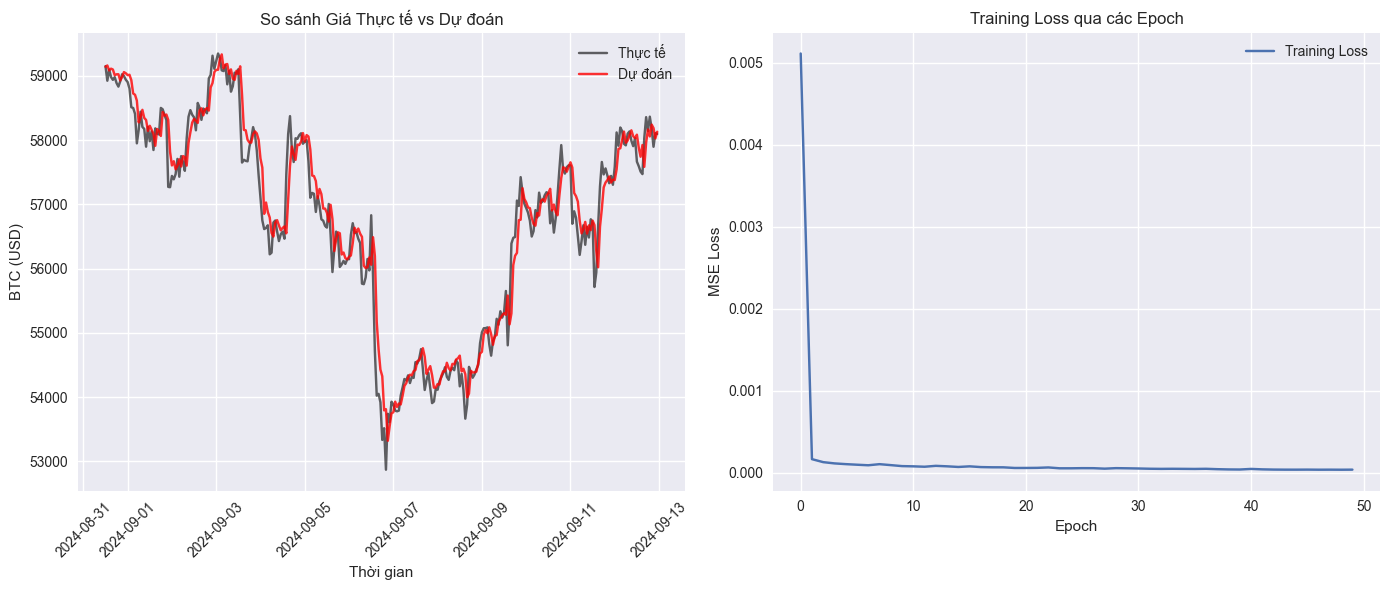

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math
import os # Thêm thư viện os để xử lý đường dẫn file
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def train_and_evaluate(save_model_path: str = None):
    """
    Train LSTM model and evaluate on test set.
    
    Args:
        save_model_path: Path to save trained model. If None, uses default path.
    """
    # 1. Config Model
    input_dim = 6  # open, high, low, close, volume, sentiment
    hidden_dim = 64
    num_layers = 2
    batch_size = 64
    epochs = 50  # Increased for better training
    learning_rate = 0.001
    
    # Feature columns used
    feature_cols = ['open', 'high', 'low', 'close', 'volume', 'sentiment']
    
    # Khởi tạo model (Đảm bảo class CryptoPredictor đã được định nghĩa ở cell trước)
    model = CryptoPredictor(input_dim, hidden_dim, num_layers, dropout=0.2).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler
    # === SỬA LỖI TẠI ĐÂY: Đã xóa verbose=True ===
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    # 2. DataLoader
    train_data = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    
    # 3. Training Loop with Early Stopping
    print("\nBắt đầu huấn luyện...")
    loss_history = []
    best_loss = float('inf')
    patience_counter = 0
    early_stop_patience = 10
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        
        # Update learning rate
        scheduler.step(avg_loss)
        
        # Early stopping check
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            # Lưu trạng thái tốt nhất tạm thời (optional)
        else:
            patience_counter += 1
            
        # In log thủ công thay cho verbose
        current_lr = optimizer.param_groups[0]['lr']
        if (epoch+1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}, Best: {best_loss:.6f}, LR: {current_lr:.6f}")
            
        if patience_counter >= early_stop_patience:
            print(f"\nEarly stopping tại epoch {epoch+1}")
            break
            
    # 4. Evaluation
    model.eval()
    with torch.no_grad():
        X_test_dev = X_test.to(DEVICE)
        predictions = model(X_test_dev).cpu().numpy()
        actuals = y_test.numpy()
        
    # Inverse Transform để về giá USD thật
    real_preds = scaler_y.inverse_transform(predictions)
    real_actuals = scaler_y.inverse_transform(actuals)
    
    # Tính RMSE
    rmse = math.sqrt(mean_squared_error(real_actuals, real_preds))
    print(f"\n=> RMSE trên tập Test: {rmse:.2f} USD")
    
    # 5. Save Model (Đã sửa lại logic lưu chuẩn)
    if save_model_path is None:
        save_model_path = "crypto_predictor_btcusdt.pt"
    
    print(f"Đang lưu model vào {save_model_path}...")
    
    # Chuẩn bị thông tin phụ
    extra_info = {
        'rmse': rmse,
        'epochs_trained': len(loss_history),
        'best_loss': best_loss
    }
    
    # Gọi hàm save_model có sẵn trong class CryptoPredictor
    model.save_model(
        path=save_model_path,
        scaler_X=scaler_X,       # Class sẽ tự chuyển đổi scaler thành dict
        scaler_y=scaler_y,       # Class sẽ tự chuyển đổi scaler thành dict
        feature_cols=feature_cols,
        window_size=WINDOW_SIZE,
        extra_info=extra_info
    )
    
    # 6. Vẽ biểu đồ
    plt.figure(figsize=(14, 6))
    
    # Biểu đồ giá
    plt.subplot(1, 2, 1)
    look_back = 300
    plt.plot(test_times[-look_back:], real_actuals[-look_back:], label='Thực tế', color='black', alpha=0.6)
    plt.plot(test_times[-look_back:], real_preds[-look_back:], label='Dự đoán', color='red', alpha=0.8)
    plt.title("So sánh Giá Thực tế vs Dự đoán")
    plt.xlabel("Thời gian")
    plt.ylabel("BTC (USD)")
    plt.legend()
    plt.xticks(rotation=45)
    
    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(loss_history, label='Training Loss')
    plt.title("Training Loss qua các Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return model, rmse

# Chạy chương trình chính nếu dữ liệu đã sẵn sàng
if 'X_train' in locals():
    trained_model, final_rmse = train_and_evaluate()

In [6]:
# =============================================================================
# TEST LOAD MODEL (Kiểm tra model đã lưu)
# =============================================================================

def test_load_model(model_path: str):
    """
    Test loading the saved model and make a sample prediction.
    """
    print(f"Loading model from: {model_path}")
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    
    # Print model info
    print("\n=== Model Configuration ===")
    config = checkpoint['model_config']
    for key, value in config.items():
        print(f"  {key}: {value}")
    
    print("\n=== Feature Columns ===")
    print(f"  {checkpoint['feature_cols']}")
    
    print(f"\n=== Window Size: {checkpoint['window_size']} ===")
    
    if 'extra_info' in checkpoint:
        print("\n=== Training Info ===")
        for key, value in checkpoint['extra_info'].items():
            print(f"  {key}: {value}")
    
    # Recreate model
    model = CryptoPredictor(
        input_dim=config['input_dim'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        output_dim=config['output_dim'],
        dropout=config['dropout']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(DEVICE)
    model.eval()
    
    print("\n✓ Model loaded successfully!")
    
    # Test inference with sample data
    if 'X_test' in globals() and len(X_test) > 0:
        with torch.no_grad():
            sample_input = X_test[:1].to(DEVICE)
            output = model(sample_input)
            print(f"\n=== Sample Prediction Test ===")
            print(f"  Input shape: {sample_input.shape}")
            print(f"  Output shape: {output.shape}")
            print(f"  Raw output: {output.cpu().numpy()[0][0]:.6f}")
            
            # Inverse transform if scaler available
            if 'scaler_y' in checkpoint:
                from sklearn.preprocessing import MinMaxScaler
                sy = MinMaxScaler()
                sy.min_ = np.array(checkpoint['scaler_y']['min_'])
                sy.scale_ = np.array(checkpoint['scaler_y']['scale_'])
                sy.data_min_ = np.array(checkpoint['scaler_y']['data_min_'])
                sy.data_max_ = np.array(checkpoint['scaler_y']['data_max_'])
                sy.data_range_ = np.array(checkpoint['scaler_y']['data_range_'])
                
                predicted_price = sy.inverse_transform(output.cpu().numpy())[0][0]
                print(f"  Predicted Price: ${predicted_price:.2f}")
    
    return model

# Test loading the saved model
MODEL_PATH = "crypto_predictor_btcusdt.pt"

try:
    if os.path.exists(MODEL_PATH):
        loaded_model = test_load_model(MODEL_PATH)
    else:
        print(f"Model file not found at: {MODEL_PATH}")
        print("Please run the training cell first to save the model.")
except Exception as e:
    print(f"Error loading model: {e}")

Loading model from: crypto_predictor_btcusdt.pt

=== Model Configuration ===
  input_dim: 6
  hidden_dim: 64
  num_layers: 2
  output_dim: 1
  dropout: 0.2

=== Feature Columns ===
  ['open', 'high', 'low', 'close', 'volume', 'sentiment']

=== Window Size: 24 ===

=== Training Info ===
  rmse: 722.2917087299286
  epochs_trained: 50
  best_loss: 3.5020310515218e-05

✓ Model loaded successfully!

=== Sample Prediction Test ===
  Input shape: torch.Size([1, 24, 6])
  Output shape: torch.Size([1, 1])
  Raw output: 0.619118
  Predicted Price: $51550.90
